In [92]:
import pandas as pd
df=pd.read_csv(r"C:\Users\Rahul Raj R\Downloads\diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [93]:
df.shape

(768, 9)

In [113]:
numerical_df = df.select_dtypes(include=['int64', 'float64'])

In [130]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
numerical_df_scaled = scaler.fit_transform(numerical_df)

numerical_df_scaled = pd.DataFrame(
    numerical_df_scaled,
    columns=numerical_df.columns,
    index=numerical_df.index
)
numerical_df_scaled=numerical_df_scaled[["Pregnancies","Glucose","BMI","Age","DiabetesPedigreeFunction"]]

In [148]:
X=numerical_df_scaled
y=df['Outcome']

In [159]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [160]:
X_train

,Pregnancies,Glucose,BMI,Age,DiabetesPedigreeFunction
60,0.117647,0.422111,0.000000,0.000000,0.096499
618,0.529412,0.562814,0.420268,0.483333,0.514091
346,0.058824,0.698492,0.427720,0.016667,0.245944
294,0.000000,0.809045,0.326379,0.733333,0.075149
231,0.352941,0.673367,0.688525,0.416667,0.068318
...,...,...,...,...,...
71,0.294118,0.698492,0.426230,0.083333,0.142186
106,0.058824,0.482412,0.333830,0.100000,0.055081
270,0.588235,0.507538,0.679583,0.283333,0.451751
435,0.000000,0.708543,0.631893,0.133333,0.054227


In [161]:
X_test

,Pregnancies,Glucose,BMI,Age,DiabetesPedigreeFunction
668,0.352941,0.492462,0.506706,0.366667,0.150299
324,0.117647,0.562814,0.532042,0.000000,0.029889
624,0.117647,0.542714,0.459016,0.000000,0.034159
690,0.470588,0.537688,0.366617,0.216667,0.332195
473,0.411765,0.683417,0.445604,0.483333,0.056362
...,...,...,...,...,...
355,0.529412,0.829146,0.453055,0.466667,0.095645
534,0.058824,0.386935,0.496274,0.050000,0.500854
344,0.470588,0.477387,0.548435,0.600000,0.173783
296,0.117647,0.733668,0.417288,0.133333,0.110589


In [162]:
y_train

60     0
618    1
346    0
294    0
231    1
      ..
71     0
106    0
270    1
435    1
102    0
Name: Outcome, Length: 614, dtype: int64

In [163]:
y_test

668    0
324    0
624    0
690    0
473    0
      ..
355    1
534    0
344    0
296    1
462    0
Name: Outcome, Length: 154, dtype: int64

In [164]:
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression(random_state=16,max_iter=100000)

In [165]:
logreg.fit(X_train,y_train)
y_pred=logreg.predict(X_test)
logreg

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",16
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [166]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

CONFUSION MATRIX:
 [[86 13]
 [22 33]]


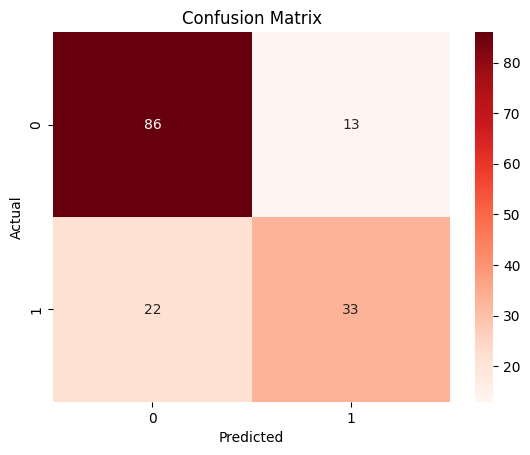

In [167]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
cnf_matrix=metrics.confusion_matrix(y_test,y_pred)
print("CONFUSION MATRIX:\n",cnf_matrix)
sns.heatmap(cnf_matrix,annot=True,cmap=plt.cm.Reds)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [168]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
acc=accuracy_score(y_test,y_pred)
pres=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print("accuracy:",acc)
print("precision:",pres)
print("recall:",recall)
print("F1:",f1)

accuracy: 0.7727272727272727
precision: 0.717391304347826
recall: 0.6
F1: 0.6534653465346535
